# 01 — Heurísticas Estruturais

Avalia métodos de predição de links baseados em heurísticas estruturais do grafo de treino (2018–2023).

Cada heurística atribui um score a um par de nós `(u, v)` com base na topologia local ou global do grafo.
Os scores são avaliados sobre os pares de validação e teste gerados em `00_generate_splits.ipynb`.

## 1. Setup

Dedicado à importação dos grafos e dos conjuntos de validação e teste (com arestas positivas e negativas).

### 1.1 Imports e configuração

In [32]:
import pandas as pd
import networkx as nx
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score
import sys

sys.path.insert(0, str(Path("../data_collection").resolve()))
from construtor_grafo import subgrafo_treino

GRAPH_PATH = Path("../data/graphs/grafo_unico.graphml")
SPLITS_DIR = Path("../data/splits")
RESULTS_DIR = Path("../data/results/heuristics")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

### 1.2 Carregamento do grafo de treino

As heurísticas são calculadas exclusivamente sobre o subgrafo de treino (2018–2023).
O grafo completo é carregado e o subgrafo de treino é extraído via bitmask.

In [33]:
G_full  = nx.read_graphml(GRAPH_PATH)
G_train = subgrafo_treino(G_full) # Remove as arestas de validação e teste do grafo

print(f"Grafo completo — nós: {G_full.number_of_nodes()}, arestas: {G_full.number_of_edges()}")
print(f"Subgrafo treino — nós: {G_train.number_of_nodes()}, arestas: {G_train.number_of_edges()}")

Grafo completo — nós: 9154, arestas: 63300
Subgrafo treino — nós: 9154, arestas: 57735


### 1.3 Carregamento dos splits

Os pares de validação e teste foram gerados em `00_generate_splits.ipynb` com proporção 1:1 (positivos:negativos).
Cada linha contém `node_u`, `node_v` e `label` (1 = aresta real, 0 = não-aresta amostrada).

In [34]:
val_df  = pd.read_csv(SPLITS_DIR / "val_pairs.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_pairs.csv")

print(f"Validação — {len(val_df)} pares ({val_df['label'].sum()} pos / {(val_df['label']==0).sum()} neg)")
print(f"Teste     — {len(test_df)} pares ({test_df['label'].sum()} pos / {(test_df['label']==0).sum()} neg)")

Validação — 6284 pares (3142 pos / 3142 neg)
Teste     — 4846 pares (2423 pos / 2423 neg)


### 1.4 Função de avaliação

Recebe uma heurística `fn(u, v) -> score` e a aplica sobre todos os pares de validação e teste.
Retorna as métricas de cada split e salva os scores em `data/results/heuristics/`.

In [35]:
def avaliar_heuristica(fn, nome):
    resultados = {}

    for split, df in [("val", val_df), ("test", test_df)]:
        scores = [fn(str(u), str(v)) for u, v in zip(df["node_u"], df["node_v"])]

        auc = roc_auc_score(df["label"], scores)
        ap  = average_precision_score(df["label"], scores)
        resultados[split] = {"auc_roc": auc, "avg_precision": ap}

        scores_df = df.copy()
        scores_df["score"]  = scores
        scores_df["method"] = nome
        scores_df.to_csv(RESULTS_DIR / f"{nome}_{split}.csv", index=False)

    print(f"{nome}")
    print(f"  val  — AUC-ROC: {resultados['val']['auc_roc']:.4f}  |  Avg Precision: {resultados['val']['avg_precision']:.4f}")
    print(f"  test — AUC-ROC: {resultados['test']['auc_roc']:.4f}  |  Avg Precision: {resultados['test']['avg_precision']:.4f}")

    return resultados

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plotar_curvas_roc(nomes):
    """Plota as curvas ROC de val e teste para cada método listado em `nomes`."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    splits = [("val", "Validação (2024)"), ("test", "Teste (2025)")]

    for ax, (split, titulo) in zip(axes, splits):
        for nome in nomes:
            csv_path = RESULTS_DIR / f"{nome}_{split}.csv"
            if not csv_path.exists():
                print(f"[aviso] {csv_path.name} não encontrado — pulando.")
                continue

            df = pd.read_csv(csv_path)
            fpr, tpr, _ = roc_curve(df["label"], df["score"])
            auc = roc_auc_score(df["label"], df["score"])
            ax.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")

        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
        ax.set_title(titulo)
        ax.set_xlabel("Taxa de falsos positivos")
        ax.set_ylabel("Taxa de verdadeiros positivos")
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## 2. Common Neighbors

A primeira estratégia aplicada para predição de links será o algoritmo de Common Neighbors, que parte da ideia de que autores que apresentam vizinhos em comum são mais prováveis de colaborarem juntos futuramente.

In [37]:
def common_neighbors_score(u, v):
    return len(list(nx.common_neighbors(G_train, u, v)))

In [38]:
resultados_common_neighbors = avaliar_heuristica(common_neighbors_score, "common_neighbors")

common_neighbors
  val  — AUC-ROC: 0.8217  |  Avg Precision: 0.8186
  test — AUC-ROC: 0.8104  |  Avg Precision: 0.8087


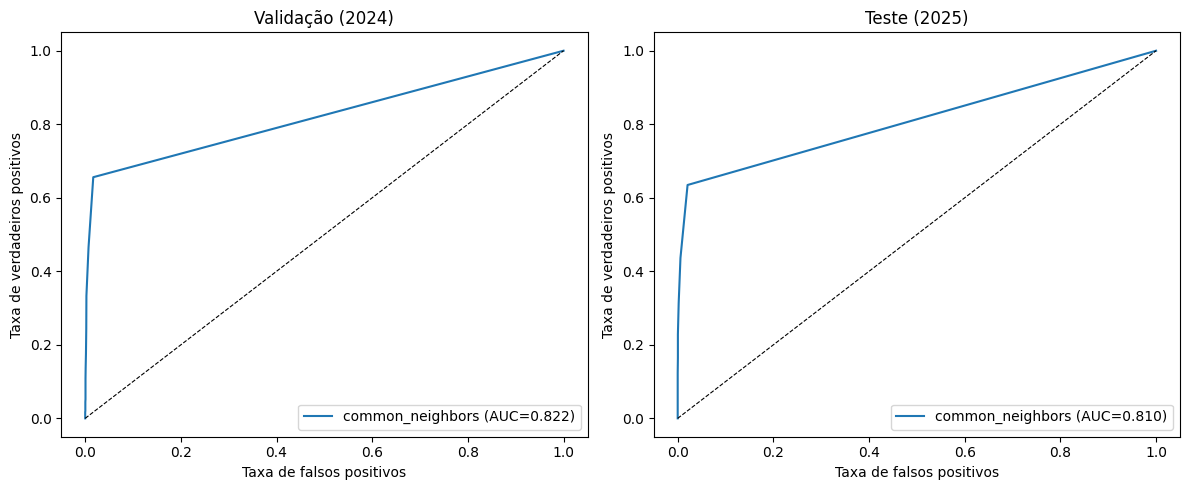

In [39]:
plotar_curvas_roc(["common_neighbors"])

É interessante notar que a curva apresenta uma alteração abrupta de comportamento ao atingir por volta de 63% da taxa de verdadeiros positivos. Isso pode indicar que aproximadamente 65% das arestas nos conjuntos de validação e teste efetivamente apresentavam vizinhos em comum nos anos de treino, e para a predição dessas arestas o algoritmo funcionou corretamente. Porém, ao avaliar as demais arestas que possivelmente não apresentavam vizinhos em comum mas colaboraram, o Common Neighbors ainda mostra-se limitado nesse contexto, evoluindo a uma taxa significativamente menor.

Além disso, é possível notar que o desempenho do conjunto de validação (arestas de 2024) mostrou-se sutilmente superior ao conjunto de teste (arestas de 2025), o que é condizente com o esperado, visto que padrões temporais mais próximos ao utilizado no treinamento tendem a ser melhores aprendidos pelo algoritmo.

## 3. Adamic-Adar


O método de Adamic-Adar consiste em uma versão ponderada do algoritmo de Common Neighbors, de modo a penalizar a influência de autores com muitas conexões no cálculo:

$$A(u, v) = \sum_{w \in N(u) \cap N(v)} \frac{1}{\log |N(w)|}$$

Ao somar o inverso do logaritmo da intersecção entre os autores, garantimos que conexões de nós com menor grau terão peso maior na predição das arestas.

In [40]:
import numpy as np

def adamic_adar_score(u, v):
    return sum(1 / np.log(nx.degree(G_train, w)) for w in nx.common_neighbors(G_train, u, v))

In [41]:
resultados_adamic_adar = avaliar_heuristica(adamic_adar_score, "adamic_adar")

adamic_adar
  val  — AUC-ROC: 0.8223  |  Avg Precision: 0.8213
  test — AUC-ROC: 0.8105  |  Avg Precision: 0.8113


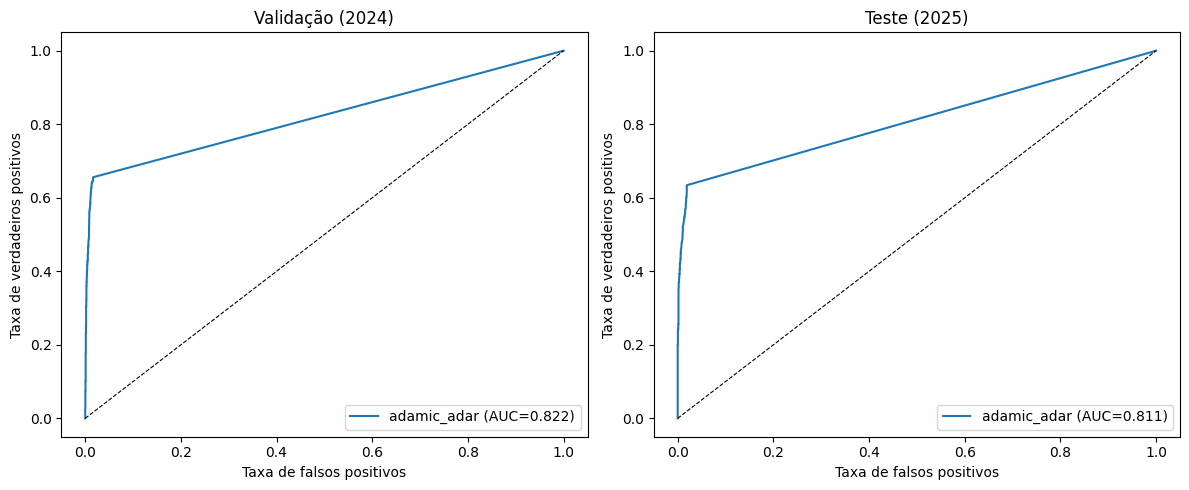

In [42]:
plotar_curvas_roc(["adamic_adar"])

Para o método de Adamic-Adar, é possível notar um desempenho relativamente similar, mas superior ao método de vizinhos em comum principalmente ao considerar a métrica de precisão média. É possível notar que as curvas se comportam muito similarmente com o método anterior, apresentado ponto de inflexão similar.

## 4. Similaridade de Jaccard

A similaridade de Jaccard consiste em dividir o tamanho da intersecção pelo tamanho da união das arestas entre dois vértices.

In [43]:
def jaccard_coefficient_score(u, v):
    preds = nx.jaccard_coefficient(G_train, [(u, v)])
    return next(preds)[2] 

In [44]:
resultados_jaccard = avaliar_heuristica(jaccard_coefficient_score, "jaccard")

jaccard
  val  — AUC-ROC: 0.8211  |  Avg Precision: 0.8182
  test — AUC-ROC: 0.8085  |  Avg Precision: 0.8050


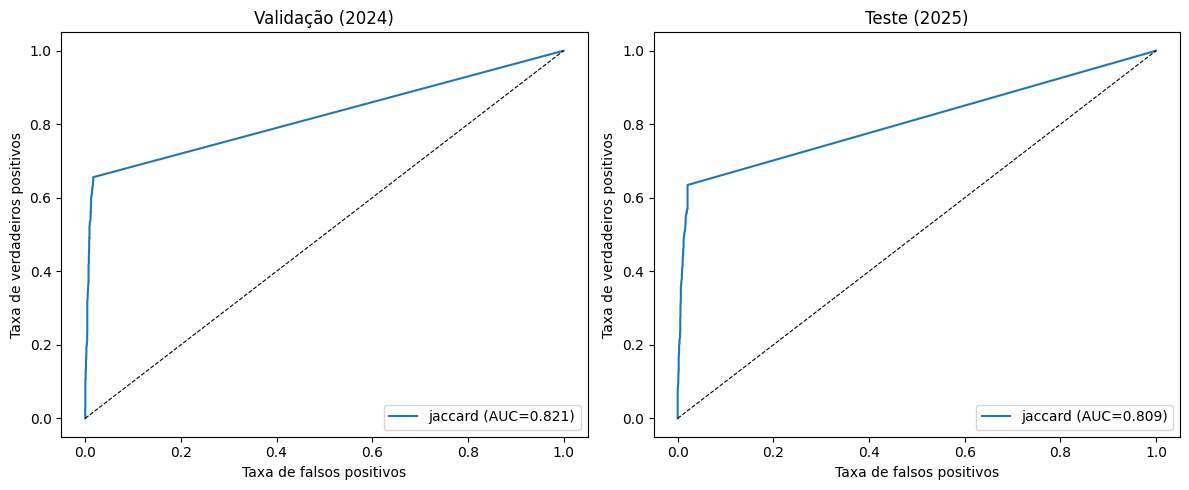

In [45]:
plotar_curvas_roc(["jaccard"])

## 5. Índice de Katz

O Índice de Katz é uma heurística **global**: ao contrário das anteriores, considera todos os caminhos entre dois nós, ponderando exponencialmente pelo comprimento do caminho com o parâmetro β:

$$\text{Katz}(u, v) = \sum_{l=1}^{L} \beta^l \cdot |A^l[u, v]|$$

onde $A^l[u,v]$ é o número de caminhos de comprimento $l$ entre $u$ e $v$.
Caminhos curtos contribuem muito; caminhos longos são quase irrelevantes. Aqui usamos uma aproximação truncada em $L = 3$. Em virtude da necessidade do cálculo da inversa da metriz de adjacência, esse método necessita maior poder computacional para grafos maiores.

**Escolha de β:** o valor deve satisfazer $\beta < 1 / \lambda_{max}$ para a série convergir.
Calculamos $\lambda_{max}$ a partir da matriz de adjacência e escolhemos um β seguro.

In [46]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# lista de nós em ordem fixa para indexar a matriz
nos      = list(G_train.nodes())
node_idx = {n: i for i, n in enumerate(nos)}
n        = len(nos)

A = nx.to_scipy_sparse_array(G_train, nodelist=nos, format="csr", dtype=float)

# maior autovalor — determina o limite superior de β
lambda_max = spla.eigsh(A, k=1, which="LM", return_eigenvectors=False)[0]
beta       = 0.8 / lambda_max  # margem de segurança de 20%

print(f"λ_max = {lambda_max:.4f}")
print(f"β escolhido = {beta:.6f}  (limite: {1/lambda_max:.6f})")

# matriz de Katz truncada: K = β*A + β²*A² + β³*A³
L  = 3
K  = sp.csr_matrix((n, n), dtype=float)
Al = sp.eye(n, format="csr", dtype=float)

for l in range(1, L + 1):
    Al = Al @ A
    K  = K + (beta ** l) * Al

print(f"\nMatriz de Katz calculada (L={L}, {n} nós)")

λ_max = 367.6365
β escolhido = 0.002176  (limite: 0.002720)

Matriz de Katz calculada (L=3, 9154 nós)


In [47]:
def katz_score(u, v):
    return K[node_idx[u], node_idx[v]]

resultados_katz = avaliar_heuristica(katz_score, "katz")

katz
  val  — AUC-ROC: 0.9172  |  Avg Precision: 0.9197
  test — AUC-ROC: 0.9142  |  Avg Precision: 0.9183


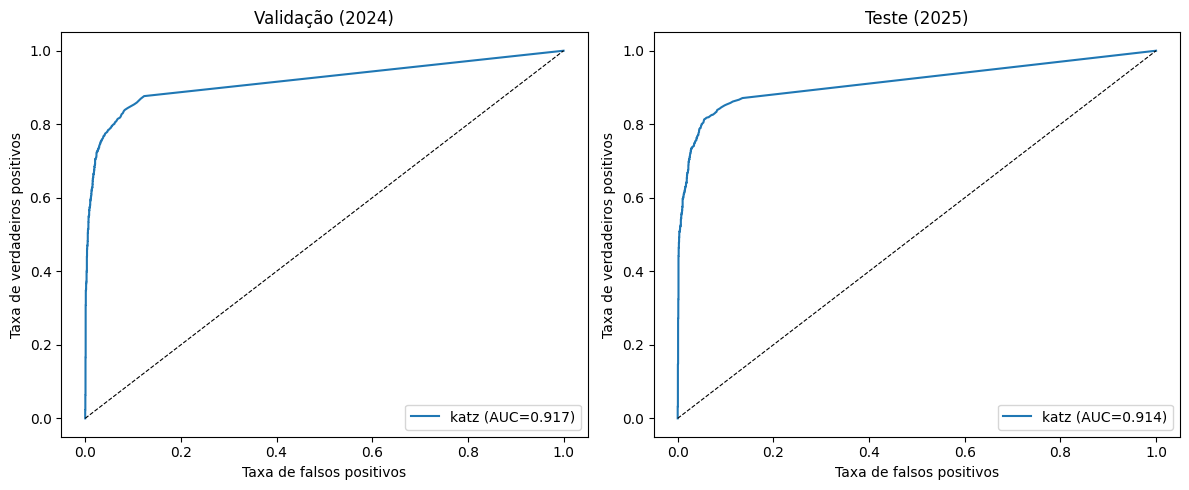

In [48]:
plotar_curvas_roc(["katz"])

## 6. Comparação entre métodos

Consolida os resultados de todas as heurísticas a partir dos arquivos de scores salvos.
Para cada método, são exibidas as métricas de validação e teste em gráficos de barras lado a lado.

          método split  AUC-ROC  Avg Precision
common_neighbors   val 0.821707       0.818628
common_neighbors  test 0.810365       0.808748
     adamic_adar   val 0.822271       0.821291
     adamic_adar  test 0.810526       0.811345
         jaccard   val 0.821145       0.818168
         jaccard  test 0.808507       0.804992
            katz   val 0.917186       0.919709
            katz  test 0.914190       0.918313


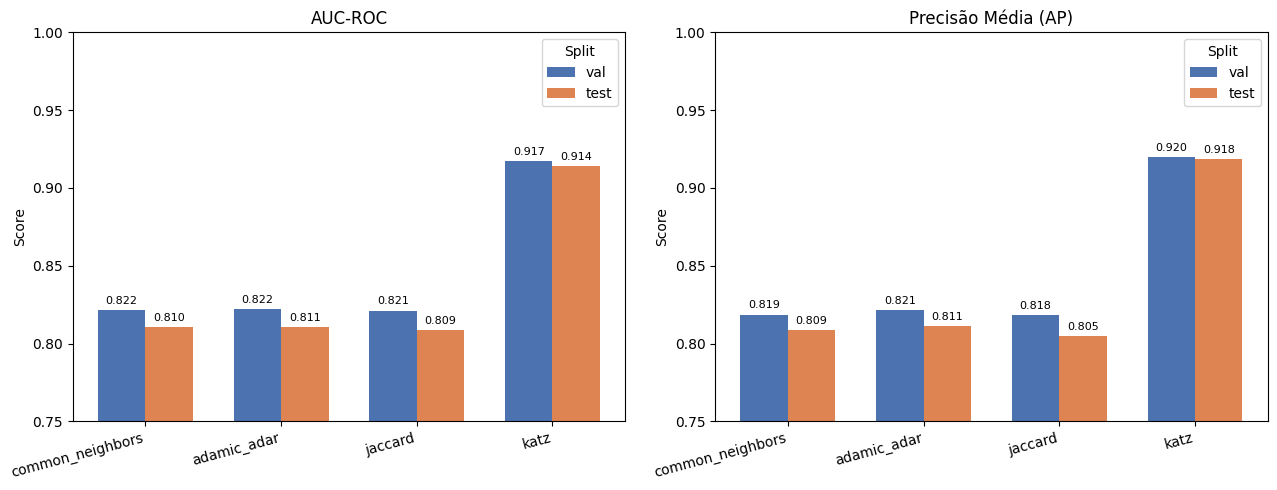

In [50]:
metodos = ["common_neighbors", "adamic_adar", "jaccard", "katz"]

rows = []
for nome in metodos:
    for split, df_split in [("val", val_df), ("test", test_df)]:
        csv_path = RESULTS_DIR / f"{nome}_{split}.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        rows.append({
            "método": nome,
            "split": split,
            "AUC-ROC": roc_auc_score(df["label"], df["score"]),
            "Avg Precision": average_precision_score(df["label"], df["score"]),
        })

comparacao_df = pd.DataFrame(rows)
print(comparacao_df.to_string(index=False))

# gráficos de barras
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metricas = ["AUC-ROC", "Avg Precision"]
titulos  = ["AUC-ROC", "Precisão Média (AP)"]
cores    = {"val": "#4C72B0", "test": "#DD8452"}
largura  = 0.35

for ax, metrica, titulo in zip(axes, metricas, titulos):
    x = range(len(metodos))
    for i, (split, cor) in enumerate(cores.items()):
        valores = [
            comparacao_df.loc[(comparacao_df["método"] == m) & (comparacao_df["split"] == split), metrica].values[0]
            for m in metodos
        ]
        offset = (i - 0.5) * largura
        bars = ax.bar([xi + offset for xi in x], valores, largura, label=split, color=cor)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    
    ax.set_title(titulo)
    ax.set_xticks(list(x))
    ax.set_xticklabels(metodos, rotation=15, ha="right")
    ax.set_ylim(0.75, 1)
    ax.set_ylabel("Score")
    ax.legend(title="Split")

plt.tight_layout()
plt.show()